# Multi-NER Menggunakan Classical Machine Learning

Notebook ini membangun **multi-named entity classification pada level teks** untuk lima NER:

1. `ORGANISASI`
2. `PLATFORM`
3. `AGE_GROUP`
4. `POLICY`
5. `DIGITAL_RISK`

Model yang dibandingkan:

- Decision Tree
- Random Forest
- XGBoost


# 1. Import Library

In [1]:
import json
import random
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    jaccard_score,
    make_scorer,
    precision_score,
    recall_score,
    multilabel_confusion_matrix
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ENTITY_LABELS = [
    "ORGANISASI",
    "PLATFORM",
    "AGE_GROUP",
    "POLICY",
    "DIGITAL_RISK",
]

EXPERIMENT_DIR = Path.cwd()
PROJECT_DIR = EXPERIMENT_DIR.parent
DATASET_DIR = PROJECT_DIR / "Dataset"
OUTPUT_DIR = PROJECT_DIR / "Outputs/Classical ML/Multi NER"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CMAPS = {
    "Decision Tree": "Blues",
    "Random Forest": "Greens",
    "XGBoost": "Reds",
}

print("Label Multi-NER:", ENTITY_LABELS)

Label Multi-NER: ['ORGANISASI', 'PLATFORM', 'AGE_GROUP', 'POLICY', 'DIGITAL_RISK']


# 2. Load Dataset

In [3]:
DATASET_NAME = DATASET_DIR / "Kelp2_dataset_anotasi_full_v2.jsonl"

CANDIDATE_PATHS = [
    Path.cwd() / DATASET_NAME,            # Folder kerja aktif
]

DATA_PATH = next((path for path in CANDIDATE_PATHS if path.is_file()), None)

if DATA_PATH is None:
    searched_paths = "\n".join(f"- {path}" for path in CANDIDATE_PATHS)
    raise FileNotFoundError(
        f"Dataset '{DATASET_NAME}' tidak ditemukan.\n"
    )

print("Dataset ditemukan:", DATA_PATH.resolve())

Dataset ditemukan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Dataset\Kelp2_dataset_anotasi_full_v2.jsonl


In [4]:
def load_jsonl(path):
    records = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSON tidak valid pada baris {line_number}: {exc}"
                ) from exc

    return records


records = load_jsonl(DATA_PATH)

print(f"Jumlah baris anotasi awal: {len(records):,}")
print("\nContoh data awal:")
display(pd.DataFrame(records[:2]))

Jumlah baris anotasi awal: 1,440

Contoh data awal:


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,config,accept,answer,_timestamp,_annotator_id,_session_id
0,Mana nih woi wes kelewatan sudah 28 maret 2026,"[{'text': 'Mana', 'start': 0, 'end': 4, 'id': ...",[],-522954419,2021888820,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLA...",blocks,{'choice_style': 'multiple'},[],accept,1776338823,apm2_genap2526-255313479,apm2_genap2526-255313479
1,Pemerintah udah keteraluan,"[{'text': 'Pemerintah', 'start': 0, 'end': 10,...","[{'start': 0, 'end': 10, 'token_start': 0, 'to...",-611415809,1993049520,"[{'id': 'PENOLAKAN_KEBIJAKAN', 'text': 'PENOLA...",blocks,{'choice_style': 'multiple'},[KRITIK_PEMERINTAHAN],accept,1776451254,apm2_genap2526-255313479,apm2_genap2526-255313479


# 3. Data Preparation

In [5]:
# Apabila satu teks dianotasi oleh beberapa annotator:
# union        = label dianggap ada jika minimal satu annotator memberi label.
# intersection = label dianggap ada hanya jika semua anotator memberi label.
MERGE_STRATEGY = "union"


def clean_text(text):
    if text is None:
        return ""

    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " USER ", text)
    text = re.sub(r"#([A-Za-z0-9_]+)", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_entity_labels(record):
    labels = {
        str(span.get("label", "")).strip()
        for span in record.get("spans", [])
        if str(span.get("label", "")).strip() in ENTITY_LABELS
    }

    return labels


def merge_label_sets(label_sets, strategy="union"):
    label_sets = list(label_sets)

    if not label_sets:
        return []

    if strategy == "union":
        merged = set().union(*label_sets)
    elif strategy == "intersection":
        merged = set.intersection(*label_sets)
    else:
        raise ValueError("MERGE_STRATEGY harus 'union' atau 'intersection'.")

    return [label for label in ENTITY_LABELS if label in merged]


def prepare_dataset(records, merge_strategy="union"):
    annotation_rows = []

    for index, record in enumerate(records):
        if record.get("answer") == "ignore":
            continue

        text = clean_text(record.get("text", ""))

        if not text:
            continue

        input_hash = record.get("_input_hash")
        group_id = str(input_hash) if input_hash is not None else text.casefold()

        annotation_rows.append(
            {
                "group_id": group_id,
                "text": text,
                "annotator": record.get(
                    "_annotator_id", f"annotator_{index}"
                ),
                "entity_labels": extract_entity_labels(record),
            }
        )

    raw_df = pd.DataFrame(annotation_rows)

    if raw_df.empty:
        raise ValueError("Tidak ada data valid setelah proses pembersihan.")

    grouped_rows = []

    for group_id, group in raw_df.groupby("group_id", sort=False):
        grouped_rows.append(
            {
                "group_id": group_id,
                "text": group["text"].iloc[0],
                "entity_labels": merge_label_sets(
                    group["entity_labels"],
                    strategy=merge_strategy,
                ),
                "n_annotators": group["annotator"].nunique(),
            }
        )

    prepared_df = pd.DataFrame(grouped_rows)
    prepared_df = (
        prepared_df
        .drop_duplicates(subset="text")
        .reset_index(drop=True)
    )

    for label in ENTITY_LABELS:
        prepared_df[label] = prepared_df["entity_labels"].apply(
            lambda labels: int(label in labels)
        )

    prepared_df["label_count"] = prepared_df[ENTITY_LABELS].sum(axis=1)

    return prepared_df


df = prepare_dataset(records, merge_strategy=MERGE_STRATEGY)

print(f"Jumlah teks unik setelah preparation: {len(df):,}")
display(df.head())

Jumlah teks unik setelah preparation: 720


,group_id,text,entity_labels,n_annotators,ORGANISASI,PLATFORM,AGE_GROUP,POLICY,DIGITAL_RISK,label_count
0,-522954419,Mana nih woi wes kelewatan sudah 28 maret 2026,[],2,0,0,0,0,0,0
1,-611415809,Pemerintah udah keteraluan,[ORGANISASI],2,1,0,0,0,0,1
2,957780750,Koruptor giliran judi ga dibasmi,[DIGITAL_RISK],2,0,0,0,0,1,1
3,-127654029,Nanggung banget 16 tahun tambahin 2 tahun kek ...,[AGE_GROUP],2,0,0,1,0,0,1
4,104677311,Kapan diterapkan dan bagaimana langkah hukumnya,[POLICY],2,0,0,0,1,0,1


In [6]:
print("Teks kosong            :", int((df["text"].str.len() == 0).sum()))
print("Duplikat teks          :", int(df["text"].duplicated().sum()))
print("Teks tanpa entitas     :", int((df["label_count"] == 0).sum()))
print("Teks dengan >1 entitas :", int((df["label_count"] > 1).sum()))

label_distribution = (
    df[ENTITY_LABELS]
    .sum()
    .sort_values(ascending=False)
    .rename("jumlah_teks")
    .to_frame()
)

print("\nDistribusi label:")
display(label_distribution)

Teks kosong            : 0
Duplikat teks          : 0
Teks tanpa entitas     : 148
Teks dengan >1 entitas : 269

Distribusi label:


,jumlah_teks
PLATFORM,273
POLICY,237
AGE_GROUP,188
ORGANISASI,141
DIGITAL_RISK,138


# 4. Feature Engineering

In [7]:
mlb = MultiLabelBinarizer(classes=ENTITY_LABELS)

X = df["text"].copy()
y = mlb.fit_transform(df["entity_labels"])

print("Urutan target :", mlb.classes_.tolist())
print("Bentuk X      :", X.shape)
print("Bentuk y      :", y.shape)
print("Contoh target :", y[:5].tolist())

Urutan target : ['ORGANISASI', 'PLATFORM', 'AGE_GROUP', 'POLICY', 'DIGITAL_RISK']
Bentuk X      : (720,)
Bentuk y      : (720, 5)
Contoh target : [[0, 0, 0, 0, 0], [1, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 1, 0, 0], [0, 0, 0, 1, 0]]


In [8]:
def multilabel_train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
):
    indices = np.arange(len(X))

    try:
        from iterstrat.ml_stratifiers import (
            MultilabelStratifiedShuffleSplit,
        )

        splitter = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=test_size,
            random_state=random_state,
        )

        train_idx, test_idx = next(splitter.split(indices, y))
        split_method = "MultilabelStratifiedShuffleSplit"

    except ImportError:
        train_idx, test_idx = train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            shuffle=True,
        )
        split_method = "train_test_split biasa"

    return (
        X.iloc[train_idx].reset_index(drop=True),
        X.iloc[test_idx].reset_index(drop=True),
        y[train_idx],
        y[test_idx],
        split_method,
    )

In [9]:
X_train, X_test, y_train, y_test, split_method = (
    multilabel_train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )
)

print("Metode split      :", split_method)
print("Jumlah data train :", len(X_train))
print("Jumlah data test  :", len(X_test))

Metode split      : MultilabelStratifiedShuffleSplit
Jumlah data train : 576
Jumlah data test  : 144


In [10]:
TFIDF_PARAMS = {
    "lowercase": True,
    "ngram_range": (1, 2),
    "max_features": 10_000,
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
}


def create_tfidf_vectorizer():
    return TfidfVectorizer(**TFIDF_PARAMS)

tfidf_preview = create_tfidf_vectorizer()
X_train_tfidf_preview = tfidf_preview.fit_transform(X_train)

print("Ukuran matriks TF-IDF :", X_train_tfidf_preview.shape)
print("Jumlah fitur          :", len(tfidf_preview.get_feature_names_out()))
print("Contoh fitur:")
print(tfidf_preview.get_feature_names_out()[:40])

Ukuran matriks TF-IDF : (576, 1283)
Jumlah fitur          : 1283
Contoh fitur:
['10' '10 tahun' '12' '12 tahun' '13' '13 tahun' '15' '15 tahun' '16'
 '16 tahun' '16 thn' '17' '17 tahun' '18' '2026' '28' '28 maret' '50'
 'abis' 'abis itu' 'ada' 'ada bocil' 'ada juga' 'ada otak' 'ada video'
 'ada yang' 'ada yg' 'ada youtube' 'adalah' 'adil' 'aduh' 'agar' 'ah'
 'ah males' 'aja' 'aja ga' 'aja kayak' 'aja masih' 'aja noh' 'aja sana']


In [11]:
CV_FOLDS = 5
train_indices = np.arange(len(X_train))

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

    cv_object = MultilabelStratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    CV_SPLITS = list(cv_object.split(train_indices, y_train))
    cv_method = "MultilabelStratifiedKFold"

except ImportError:
    cv_object = KFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    CV_SPLITS = list(cv_object.split(train_indices))
    cv_method = "KFold biasa"

SCORING = {
    "f1_micro": make_scorer(
        f1_score,
        average="micro",
        zero_division=0,
    ),
    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "hamming_loss": make_scorer(
        hamming_loss,
        greater_is_better=False,
    ),
}

print("Metode cross-validation :", cv_method)
print("Jumlah fold             :", len(CV_SPLITS))

Metode cross-validation : MultilabelStratifiedKFold
Jumlah fold             : 5


# 7. Fungsi Training, Classification Report, Evaluasi, dan Penyimpanan

Fungsi dipisahkan berdasarkan tujuan:

- `run_grid_search()` hanya menjalankan GridSearchCV dan menghasilkan seluruh hasil tuning.
- `generate_oof_training_report()` membuat prediksi out-of-fold serta classification report training.
- `evaluate_model()` hanya menghitung dan menampilkan metrik pada data test.
- `build_confusion_matrix()` dan `plot_confusion()` dipakai pada sel confusion matrix yang terpisah.
- `save_best_model_joblib()` menyimpan pipeline terbaik dalam format `.joblib`.

In [12]:
def get_selected_cv_results(search):
    cv_df = pd.DataFrame(search.cv_results_).copy()

    selected_columns = [
        column
        for column in cv_df.columns
        if column.startswith("param_")
        or column
        in {
            "rank_test_f1_micro",
            "mean_test_f1_micro",
            "std_test_f1_micro",
            "mean_test_f1_macro",
            "std_test_f1_macro",
            "mean_test_hamming_loss",
            "std_test_hamming_loss",
        }
    ]

    result = (
        cv_df[selected_columns]
        .sort_values("rank_test_f1_micro")
        .reset_index(drop=True)
    )

    if "mean_test_hamming_loss" in result.columns:
        result["mean_hamming_loss"] = -result["mean_test_hamming_loss"]

    return result

def run_grid_search(
    model_name,
    pipeline,
    param_grid,
    X_train,
    y_train,
    scoring,
    cv,
    refit_metric="f1_micro",
    top_n=10,
    n_jobs=-1,
    verbose=1,
):

    print("=" * 80)
    print(f"{model_name} - MULTI-NER TRAINING")
    print("=" * 80)

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit=refit_metric,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        return_train_score=False,
        error_score="raise",
    )

    search.fit(X_train, y_train)

    # Seluruh hasil GridSearchCV
    cv_results = pd.DataFrame(search.cv_results_)

    # Mengubah dictionary parameter menjadi beberapa kolom
    parameter_columns = pd.json_normalize(cv_results["params"])

    # Menghapus awalan nama pipeline
    parameter_columns.columns = [
        column.replace("classifier__estimator__", "")
        for column in parameter_columns.columns
    ]

    # Membuat ringkasan hasil
    grid_summary = parameter_columns.copy()

    grid_summary["F1-micro"] = cv_results[
        "mean_test_f1_micro"
    ]

    grid_summary["F1-macro"] = cv_results[
        "mean_test_f1_macro"
    ]

    # Hamming Loss disimpan dalam bentuk negatif oleh GridSearchCV
    if "mean_test_hamming_loss" in cv_results.columns:
        grid_summary["Hamming Loss"] = (
            -cv_results["mean_test_hamming_loss"]
        )

    grid_summary["Std F1-micro"] = cv_results[
        "std_test_f1_micro"
    ]

    # Mengurutkan kombinasi terbaik
    sort_columns = [
        "F1-micro",
        "F1-macro",
    ]

    ascending_values = [
        False,
        False,
    ]

    if "Hamming Loss" in grid_summary.columns:
        sort_columns.append("Hamming Loss")
        ascending_values.append(True)

    grid_summary = (
        grid_summary
        .sort_values(
            by=sort_columns,
            ascending=ascending_values,
        )
        .reset_index(drop=True)
    )

    print("\nParameter terbaik:")

    for parameter_name, parameter_value in search.best_params_.items():
        clean_name = parameter_name.replace(
            "classifier__estimator__",
            "",
        )

        print(f"- {clean_name}: {parameter_value}")

    best_index = search.best_index_

    print(
        f"\nBest CV F1-micro     : "
        f"{cv_results.loc[best_index, 'mean_test_f1_micro']:.4f}"
    )

    print(
        f"Best CV F1-macro     : "
        f"{cv_results.loc[best_index, 'mean_test_f1_macro']:.4f}"
    )

    if "mean_test_hamming_loss" in cv_results.columns:
        best_hamming_loss = -cv_results.loc[
            best_index,
            "mean_test_hamming_loss",
        ]

        print(
            f"Best CV Hamming Loss : "
            f"{best_hamming_loss:.4f}"
        )

    # Menampilkan kombinasi terbaik
    jumlah_ditampilkan = min(
        top_n,
        len(grid_summary),
    )

    print("\n" + "=" * 80)
    print(
        f"{jumlah_ditampilkan} KOMBINASI PARAMETER "
        f"TERBAIK - {model_name.upper()}"
    )
    print("=" * 80)

    top_combinations = grid_summary.head(
        jumlah_ditampilkan
    )

    format_columns = {
        "F1-micro": "{:.4f}",
        "F1-macro": "{:.4f}",
        "Std F1-micro": "{:.4f}",
    }

    if "Hamming Loss" in top_combinations.columns:
        format_columns["Hamming Loss"] = "{:.4f}"

    display(
        top_combinations.style.format(
            format_columns
        )
    )

    return search, cv_results, grid_summary

In [13]:
def calculate_accuracy_metrics(y_true, y_pred):
    subset_accuracy = accuracy_score(y_true, y_pred)
    label_accuracy = 1.0 - hamming_loss(y_true, y_pred)
    return subset_accuracy, label_accuracy


def evaluate_model_metrics(y_true, y_pred):
    subset_acc, label_acc = calculate_accuracy_metrics(y_true, y_pred)

    return {
        "hamming_loss": hamming_loss(y_true, y_pred),
        "label_accuracy": label_acc,
        "subset_accuracy": subset_acc,
        "precision_micro": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "recall_micro": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "f1_micro": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_samples": f1_score(
            y_true, y_pred, average="samples", zero_division=0
        ),
        "jaccard_samples": jaccard_score(
            y_true, y_pred, average="samples", zero_division=0
        ),
    }


def generate_oof_training_report(
    model_name,
    search,
    X_train,
    y_train,
    cv,
    labels,
):
    print("\nMembuat prediksi out-of-fold untuk seluruh data training...")

    oof_predictions = cross_val_predict(
        estimator=search.best_estimator_,
        X=X_train,
        y=y_train,
        cv=cv,
        method="predict",
        n_jobs=-1,
    )
    oof_predictions = np.asarray(oof_predictions, dtype=int)

    report_text = classification_report(
        y_train,
        oof_predictions,
        target_names=labels,
        digits=4,
        zero_division=0,
    )
    report_dict = classification_report(
        y_train,
        oof_predictions,
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T

    training_metrics = evaluate_model_metrics(y_train, oof_predictions)
    training_summary = pd.DataFrame(
        [{"model": model_name, **training_metrics}]
    )

    print(f"\nClassification Report {model_name} :")
    print(report_text)
    print("Accuracy untuk multi-NER:")
    print(f"- Subset Accuracy : {training_metrics['subset_accuracy']:.4f}")
    print(f"- Label Accuracy  : {training_metrics['label_accuracy']:.4f}")

    return report_df, training_summary, oof_predictions

In [14]:
def get_probabilities(model, X):
    if not hasattr(model, "predict_proba"):
        raise AttributeError("Model tidak memiliki metode predict_proba().")

    probabilities = model.predict_proba(X)

    # Sebagian estimator multi-output dapat menghasilkan list array.
    if isinstance(probabilities, list):
        positive_columns = []
        for output_probability in probabilities:
            output_probability = np.asarray(output_probability)
            if output_probability.ndim == 2 and output_probability.shape[1] > 1:
                positive_columns.append(output_probability[:, 1])
            else:
                positive_columns.append(output_probability.reshape(-1))
        return np.column_stack(positive_columns)

    probabilities = np.asarray(probabilities)

    if probabilities.ndim == 3:
        if probabilities.shape[-1] == 2:
            probabilities = probabilities[:, :, 1].T
        else:
            raise ValueError(
                f"Bentuk probabilitas tidak dikenali: {probabilities.shape}"
            )

    if probabilities.ndim != 2:
        raise ValueError(
            f"Bentuk probabilitas harus 2 dimensi, diperoleh {probabilities.shape}."
        )

    return probabilities


def build_confusion_matrix(model, X_test, y_test, labels):
    y_test_array = np.asarray(y_test)
    single_label_mask = y_test_array.sum(axis=1) == 1
    used_count = int(single_label_mask.sum())

    if used_count == 0:
        raise ValueError(
            "Tidak ada data test dengan tepat satu label untuk confusion matrix."
        )

    y_true_single = np.argmax(y_test_array[single_label_mask], axis=1)
    probabilities = get_probabilities(model, X_test)
    y_pred_single = np.argmax(probabilities[single_label_mask], axis=1)

    matrix = confusion_matrix(
        y_true_single,
        y_pred_single,
        labels=np.arange(len(labels)),
    )
    return matrix, used_count


def plot_confusion(matrix, labels, title, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(9, 7))
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=labels,
    )
    display_matrix.plot(
        ax=ax,
        cmap=cmap,
        values_format="d",
        colorbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [15]:
def evaluate_model(
    model_name,
    model,
    X_test,
    y_test,
):
    print(f"{model_name} - EVALUATION MODEL")
    print("=" * 80)

    y_pred = np.asarray(model.predict(X_test), dtype=int)
    metrics = evaluate_model_metrics(y_test, y_pred)
    metrics_df = pd.DataFrame([{"model": model_name, **metrics}])

    print("\nMetrik Evaluasi pada Data Test:")
    display(metrics_df)

    return metrics_df

In [16]:
def save_best_model_joblib(
    search,
    model_name,
    filename,
    output_dir=OUTPUT_DIR,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / filename

    payload = {
        "model_name": model_name,
        "pipeline": search.best_estimator_,
        "best_params": search.best_params_,
        "entity_labels": ENTITY_LABELS,
        "multilabel_binarizer": mlb,
        "merge_strategy": MERGE_STRATEGY,
        "tfidf_params": TFIDF_PARAMS,
        "random_state": RANDOM_STATE,
    }

    joblib.dump(payload, model_path)
    print(f"\nModel tersimpan: {model_path.resolve()}")
    return model_path

In [17]:
def build_multilabel_confusion_matrix(
    model,
    X_test,
    y_test,
):
    y_true = np.asarray(y_test, dtype=int)

    # Menggunakan metode prediksi yang sama dengan evaluation model
    y_pred = np.asarray(
        model.predict(X_test),
        dtype=int,
    )

    matrices = multilabel_confusion_matrix(
        y_true,
        y_pred,
    )

    return matrices, y_pred

def plot_multilabel_confusion(
    matrices,
    labels,
    model_name,
    cmap="Blues"
):
    # Membuat 1 baris dengan jumlah kolom sesuai jumlah NER
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(labels),
        figsize=(5 * len(labels), 4.5)
    )

    # Agar tetap berjalan jika hanya terdapat satu label
    if len(labels) == 1:
        axes = [axes]

    for ax, label, matrix in zip(axes, labels, matrices):

        display = ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=[
                "Tidak Terdeteksi",
                "Terdeteksi"
            ]
        )

        display.plot(
            ax=ax,
            cmap=cmap,
            values_format="d",
            colorbar=False
        )

        ax.set_title(
            label,
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Aktual")

    fig.suptitle(
        f"Confusion Matrix Multi-NER – {model_name}",
        fontsize=16,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()

    # Hanya satu kali show untuk seluruh NER
    plt.show()

# 8. Training

## Decision Tree

In [18]:
decision_tree_pipeline = Pipeline(
    [
        ("tfidf", create_tfidf_vectorizer()),
        (
            "classifier",
            OneVsRestClassifier(
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                ),
                n_jobs=1,
            ),
        ),
    ]
)

In [19]:
decision_tree_param_grid = {
    "classifier__estimator__criterion": ["gini", "entropy"],
    "classifier__estimator__max_depth": [10, 20, 30],
    "classifier__estimator__min_samples_split": [2, 5, 10],
    "classifier__estimator__min_samples_leaf": [1, 2],
}

(
    decision_tree_search,
    dt_cv_results,
    dt_grid_summary,
) = run_grid_search(
    model_name="Decision Tree",
    pipeline=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    X_train=X_train,
    y_train=y_train,
    scoring=SCORING,
    cv=CV_SPLITS,
    refit_metric="f1_micro",
    top_n=10, 
)

dt_model_path = save_best_model_joblib(
    search=decision_tree_search,
    model_name="Decision Tree",
    filename="decision_tree_multi_ner.joblib",
)

Decision Tree - MULTI-NER TRAINING
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Parameter terbaik:
- criterion: entropy
- max_depth: 10
- min_samples_leaf: 1
- min_samples_split: 2

Best CV F1-micro     : 0.8024
Best CV F1-macro     : 0.8115
Best CV Hamming Loss : 0.1014

10 KOMBINASI PARAMETER TERBAIK - DECISION TREE


,criterion,max_depth,min_samples_leaf,min_samples_split,F1-micro,F1-macro,Hamming Loss,Std F1-micro
0,entropy,10,1,2,0.8024,0.8115,0.1014,0.0211
1,entropy,10,1,5,0.8001,0.8076,0.1035,0.0216
2,entropy,10,2,5,0.7999,0.8069,0.1045,0.0182
3,entropy,30,1,5,0.7991,0.8079,0.1083,0.0190
4,entropy,10,2,2,0.7980,0.8054,0.1052,0.0170
5,gini,10,2,5,0.7973,0.8061,0.1063,0.0237
6,gini,10,2,2,0.7951,0.8044,0.1073,0.0214
7,entropy,10,1,10,0.7943,0.8007,0.1080,0.0209
8,gini,10,1,2,0.7940,0.8039,0.1066,0.0279
9,entropy,20,1,5,0.7938,0.8022,0.1097,0.0230



Model tersimpan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Classical ML\Multi NER\decision_tree_multi_ner.joblib


### Classification Report

In [20]:
(
    dt_training_report,
    dt_training_summary,
    dt_oof_predictions,
) = generate_oof_training_report(
    model_name="Decision Tree",
    search=decision_tree_search,
    X_train=X_train,
    y_train=y_train,
    cv=CV_SPLITS,
    labels=ENTITY_LABELS,
)


Membuat prediksi out-of-fold untuk seluruh data training...

Classification Report Decision Tree :
              precision    recall  f1-score   support

  ORGANISASI     0.8952    0.8319    0.8624       113
    PLATFORM     0.9076    0.7661    0.8308       218
   AGE_GROUP     0.8523    0.8467    0.8495       150
      POLICY     0.7226    0.5895    0.6493       190
DIGITAL_RISK     0.8942    0.8455    0.8692       110

   micro avg     0.8508    0.7593    0.8024       781
   macro avg     0.8544    0.7759    0.8122       781
weighted avg     0.8483    0.7593    0.8002       781
 samples avg     0.6176    0.5975    0.5905       781

Accuracy untuk multi-NER:
- Subset Accuracy : 0.5799
- Label Accuracy  : 0.8986


### Evaluation Model

In [21]:
dt_metrics = evaluate_model(
    model_name="Decision Tree",
    model=decision_tree_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
)

Decision Tree - EVALUATION MODEL

Metrik Evaluasi pada Data Test:


,model,hamming_loss,label_accuracy,subset_accuracy,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,f1_samples,jaccard_samples
0,Decision Tree,0.083333,0.916667,0.631944,0.9,0.780612,0.836066,0.90257,0.797181,0.845131,0.833822,0.583036,0.54919


### Confusion Matrix

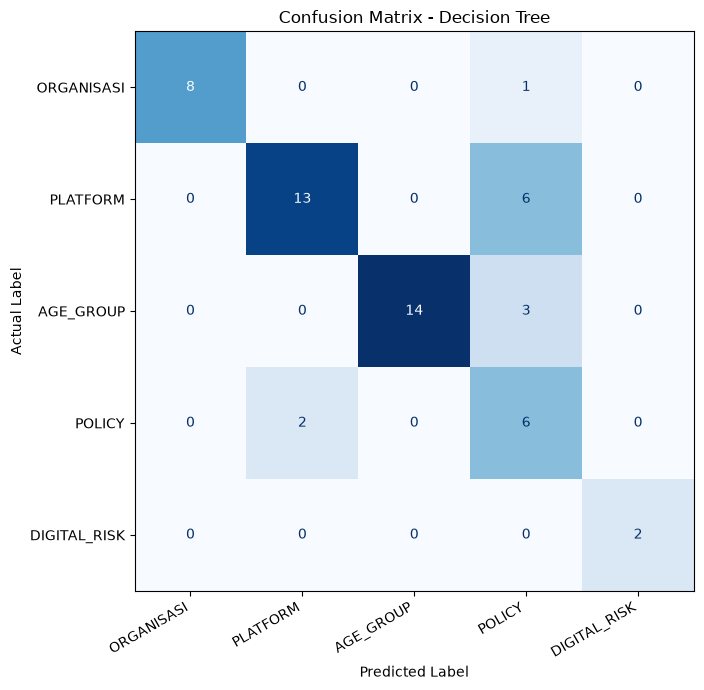

In [22]:
dt_confusion_matrix, dt_cm_used_count = build_confusion_matrix(
    model=decision_tree_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    labels=ENTITY_LABELS,
)

dt_confusion_df = pd.DataFrame(
    dt_confusion_matrix,
    index=pd.Index(ENTITY_LABELS, name="Actual"),
    columns=pd.Index(ENTITY_LABELS, name="Predicted"),
)

plot_confusion(
    matrix=dt_confusion_matrix,
    labels=ENTITY_LABELS,
    title="Confusion Matrix - Decision Tree",
    cmap=MODEL_CMAPS.get("Decision Tree", "Blues"),
)

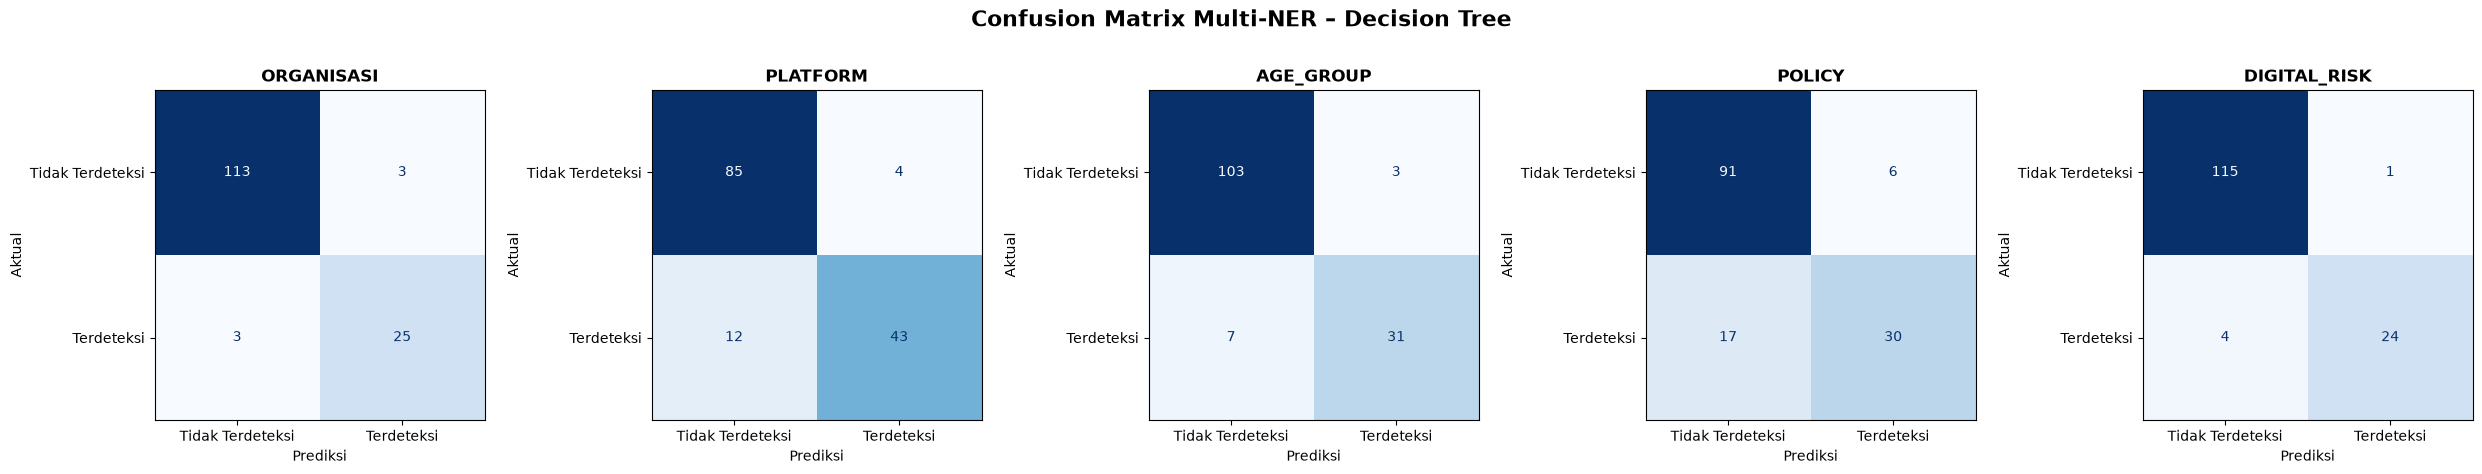

In [23]:
dt_multilabel_cm, dt_test_predictions = (
    build_multilabel_confusion_matrix(
        model=decision_tree_search.best_estimator_,
        X_test=X_test,
        y_test=y_test,
    )
)

plot_multilabel_confusion(
    matrices=dt_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="Decision Tree",
    cmap=MODEL_CMAPS.get(
        "Decision Tree",
        "Blues",
    ),
)

## Random Forest

In [24]:
random_forest_pipeline = Pipeline(
    [
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            OneVsRestClassifier(
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=1,
                ),
                n_jobs=1,
            ),
        ),
    ]
)

In [25]:
random_forest_param_grid = {
    "classifier__estimator__n_estimators": [100, 200, 300],
    "classifier__estimator__max_depth": [10, 20, 50],
    "classifier__estimator__min_samples_split": [2, 5, 10],
    "classifier__estimator__min_samples_leaf": [1, 2, 5],
    "classifier__estimator__max_features": ["sqrt"],
}

(
    random_forest_search,
    rf_cv_results,
    rf_grid_summary,
) = run_grid_search(
    model_name="Random Forest",
    pipeline=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    X_train=X_train,
    y_train=y_train,
    scoring=SCORING,
    cv=CV_SPLITS,
    refit_metric="f1_micro",
    top_n=10,
)

rf_model_path = save_best_model_joblib(
    search=random_forest_search,
    model_name="Random Forest",
    filename="random_forest_multi_ner.joblib",
)

Random Forest - MULTI-NER TRAINING
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Parameter terbaik:
- max_depth: 50
- max_features: sqrt
- min_samples_leaf: 1
- min_samples_split: 10
- n_estimators: 300

Best CV F1-micro     : 0.8190
Best CV F1-macro     : 0.8237
Best CV Hamming Loss : 0.0938

10 KOMBINASI PARAMETER TERBAIK - RANDOM FOREST


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,F1-micro,F1-macro,Hamming Loss,Std F1-micro
0,50,sqrt,1,10,300,0.8190,0.8237,0.0938,0.0266
1,50,sqrt,1,5,100,0.8173,0.8233,0.0944,0.0241
2,50,sqrt,1,5,300,0.8166,0.8206,0.0941,0.0278
3,50,sqrt,1,5,200,0.8151,0.8187,0.0948,0.0265
4,50,sqrt,1,2,300,0.8146,0.8187,0.0934,0.0271
5,50,sqrt,1,10,200,0.8141,0.8183,0.0962,0.0252
6,50,sqrt,1,10,100,0.8122,0.8186,0.0979,0.0257
7,50,sqrt,1,2,200,0.8116,0.8158,0.0951,0.0276
8,50,sqrt,2,10,300,0.8107,0.8161,0.0976,0.0253
9,50,sqrt,2,2,200,0.8080,0.8121,0.0983,0.0247



Model tersimpan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Classical ML\Multi NER\random_forest_multi_ner.joblib


### Classification Report

In [26]:
(
    rf_training_report,
    rf_training_summary,
    rf_oof_predictions,
) = generate_oof_training_report(
    model_name="Random Forest",
    search=random_forest_search,
    X_train=X_train,
    y_train=y_train,
    cv=CV_SPLITS,
    labels=ENTITY_LABELS,
)


Membuat prediksi out-of-fold untuk seluruh data training...

Classification Report Random Forest :
              precision    recall  f1-score   support

  ORGANISASI     0.8936    0.7434    0.8116       113
    PLATFORM     0.8627    0.8073    0.8341       218
   AGE_GROUP     0.8859    0.8800    0.8829       150
      POLICY     0.7730    0.6632    0.7139       190
DIGITAL_RISK     0.9126    0.8545    0.8826       110

   micro avg     0.8583    0.7836    0.8193       781
   macro avg     0.8656    0.7897    0.8250       781
weighted avg     0.8569    0.7836    0.8178       781
 samples avg     0.6227    0.6115    0.6019       781

Accuracy untuk multi-NER:
- Subset Accuracy : 0.6146
- Label Accuracy  : 0.9062


### Evaluation Model

In [27]:
rf_metrics = evaluate_model(
    model_name="Random Forest",
    model=random_forest_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
)

Random Forest - EVALUATION MODEL

Metrik Evaluasi pada Data Test:


,model,hamming_loss,label_accuracy,subset_accuracy,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,f1_samples,jaccard_samples
0,Random Forest,0.077778,0.922222,0.673611,0.860825,0.852041,0.85641,0.871295,0.851917,0.860505,0.856761,0.640945,0.606944


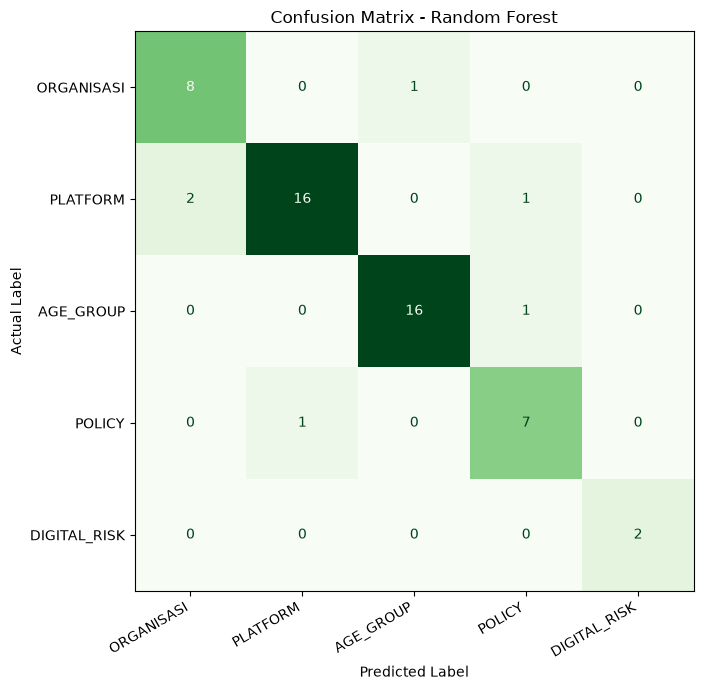

In [28]:
rf_confusion_matrix, rf_cm_used_count = build_confusion_matrix(
    model=random_forest_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    labels=ENTITY_LABELS,
)

rf_confusion_df = pd.DataFrame(
    rf_confusion_matrix,
    index=pd.Index(ENTITY_LABELS, name="Actual"),
    columns=pd.Index(ENTITY_LABELS, name="Predicted"),
)

plot_confusion(
    matrix=rf_confusion_matrix,
    labels=ENTITY_LABELS,
    title="Confusion Matrix - Random Forest",
    cmap=MODEL_CMAPS.get("Random Forest", "Greens"),
)

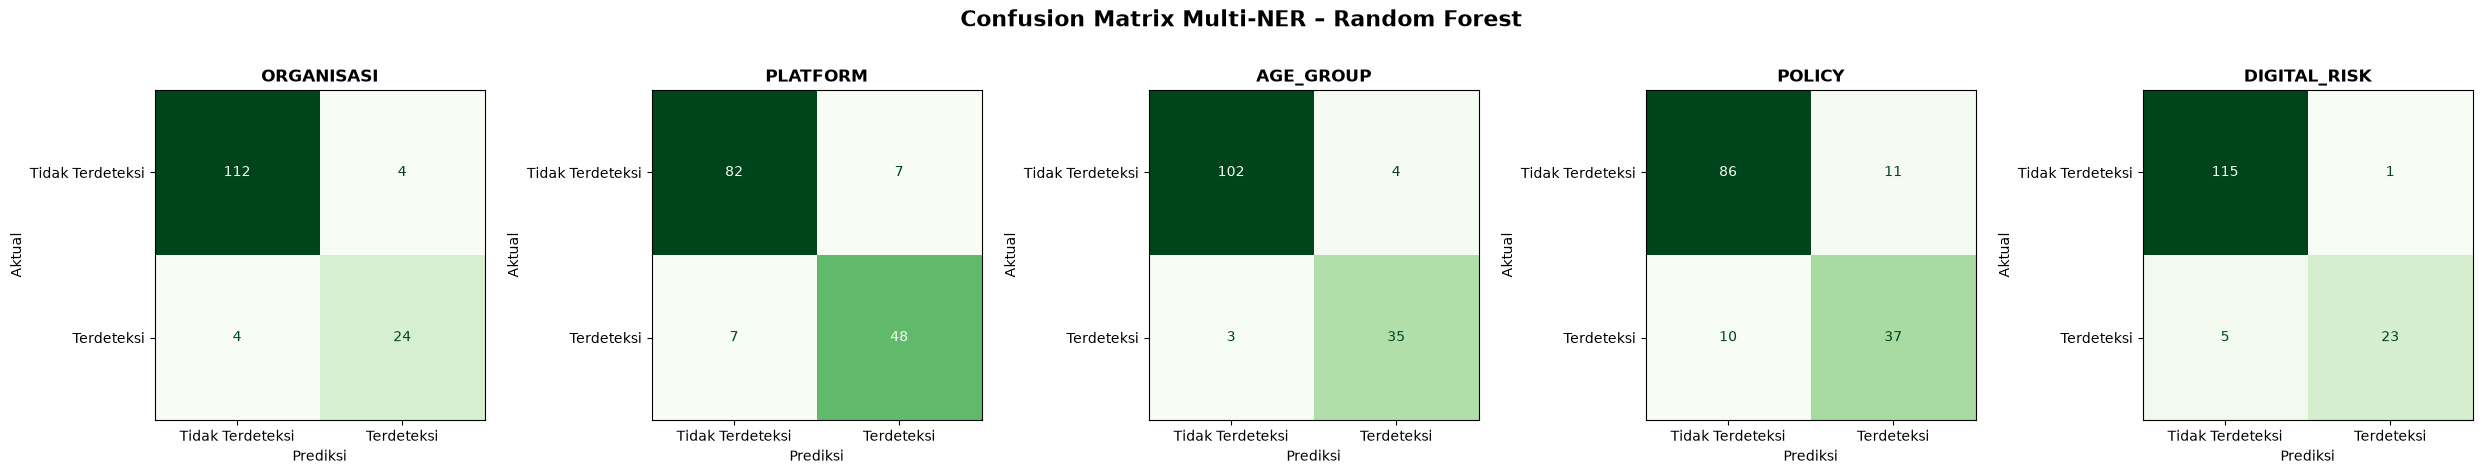

In [29]:
rf_multilabel_cm, rf_test_predictions = (
    build_multilabel_confusion_matrix(
        model=random_forest_search.best_estimator_,
        X_test=X_test,
        y_test=y_test,
    )
)

plot_multilabel_confusion(
    matrices=rf_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="Random Forest",
    cmap=MODEL_CMAPS.get(
        "Random Forest",
        "Greens",
    ),
)

## XGBoost

In [30]:
xgboost_pipeline = Pipeline(
    [
        (
            "tfidf",
            create_tfidf_vectorizer(),
        ),
        (
            "classifier",
            OneVsRestClassifier(
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    tree_method="hist",
                    n_jobs=1,
                    verbosity=0,
                ),
                n_jobs=1,
            ),
        ),
    ]
)

In [31]:
xgboost_param_grid = {
    "classifier__estimator__n_estimators": [100, 200, 500],
    "classifier__estimator__max_depth": [3, 5, 7],
    "classifier__estimator__learning_rate": [0.05, 0.1],
    "classifier__estimator__subsample": [0.8, 1.0],
    "classifier__estimator__colsample_bytree": [ 0.8],
}

(
    xgboost_search,
    xgb_cv_results,
    xgb_grid_summary,
) = run_grid_search(
    model_name="XGBoost",
    pipeline=xgboost_pipeline,
    param_grid=xgboost_param_grid,
    X_train=X_train,
    y_train=y_train,
    scoring=SCORING,
    cv=CV_SPLITS,
    refit_metric="f1_micro",
    top_n=10,
)

xgb_model_path = save_best_model_joblib(
    search=xgboost_search,
    model_name="XGBoost",
    filename="xgboost_multi_ner.joblib",
)

XGBoost - MULTI-NER TRAINING
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Parameter terbaik:
- colsample_bytree: 0.8
- learning_rate: 0.1
- max_depth: 5
- n_estimators: 100
- subsample: 1.0

Best CV F1-micro     : 0.7828
Best CV F1-macro     : 0.7902
Best CV Hamming Loss : 0.1059

10 KOMBINASI PARAMETER TERBAIK - XGBOOST


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,F1-micro,F1-macro,Hamming Loss,Std F1-micro
0,0.800000,0.100000,5,100,1.000000,0.7828,0.7902,0.1059,0.0242
1,0.800000,0.050000,7,100,1.000000,0.7810,0.7874,0.1049,0.0283
2,0.800000,0.050000,7,200,1.000000,0.7810,0.7891,0.1077,0.0324
3,0.800000,0.050000,5,200,1.000000,0.7804,0.7876,0.1073,0.0300
4,0.800000,0.100000,7,100,1.000000,0.7796,0.7883,0.1087,0.0320
5,0.800000,0.100000,5,100,0.800000,0.7785,0.7857,0.1073,0.0327
6,0.800000,0.100000,3,200,1.000000,0.7769,0.7839,0.1080,0.0264
7,0.800000,0.100000,3,200,0.800000,0.7767,0.7822,0.1090,0.0323
8,0.800000,0.050000,3,500,1.000000,0.7747,0.7822,0.1094,0.0303
9,0.800000,0.050000,5,100,1.000000,0.7739,0.7825,0.1073,0.0308



Model tersimpan: D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Classical ML\Multi NER\xgboost_multi_ner.joblib


### Classification Report

In [32]:
(
    xgb_training_report,
    xgb_training_summary,
    xgb_oof_predictions,
) = generate_oof_training_report(
    model_name="XGBoost",
    search=xgboost_search,
    X_train=X_train,
    y_train=y_train,
    cv=CV_SPLITS,
    labels=ENTITY_LABELS,
)


Membuat prediksi out-of-fold untuk seluruh data training...

Classification Report XGBoost :
              precision    recall  f1-score   support

  ORGANISASI     0.9310    0.7168    0.8100       113
    PLATFORM     0.9091    0.7339    0.8122       218
   AGE_GROUP     0.8889    0.8000    0.8421       150
      POLICY     0.7594    0.5316    0.6254       190
DIGITAL_RISK     0.9462    0.8000    0.8670       110

   micro avg     0.8814    0.7042    0.7829       781
   macro avg     0.8869    0.7165    0.7913       781
weighted avg     0.8772    0.7042    0.7799       781
 samples avg     0.5894    0.5496    0.5548       781

Accuracy untuk multi-NER:
- Subset Accuracy : 0.5781
- Label Accuracy  : 0.8941


### Evaluation Model

In [33]:
xgb_metrics = evaluate_model(
    model_name="XGBoost",
    model=xgboost_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
)

XGBoost - EVALUATION MODEL

Metrik Evaluasi pada Data Test:


,model,hamming_loss,label_accuracy,subset_accuracy,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,f1_samples,jaccard_samples
0,XGBoost,0.088889,0.911111,0.631944,0.89759,0.760204,0.823204,0.899111,0.772022,0.827051,0.816967,0.583587,0.54838


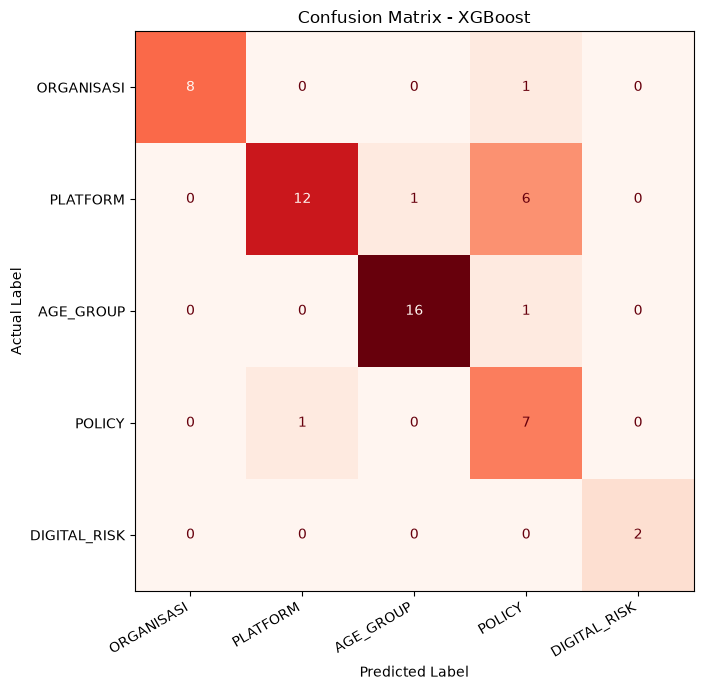

In [34]:
xgb_confusion_matrix, xgb_cm_used_count = build_confusion_matrix(
    model=xgboost_search.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    labels=ENTITY_LABELS,
)

xgb_confusion_df = pd.DataFrame(
    xgb_confusion_matrix,
    index=pd.Index(ENTITY_LABELS, name="Actual"),
    columns=pd.Index(ENTITY_LABELS, name="Predicted"),
)

plot_confusion(
    matrix=xgb_confusion_matrix,
    labels=ENTITY_LABELS,
    title="Confusion Matrix - XGBoost",
    cmap=MODEL_CMAPS.get("XGBoost", "Reds"),
)

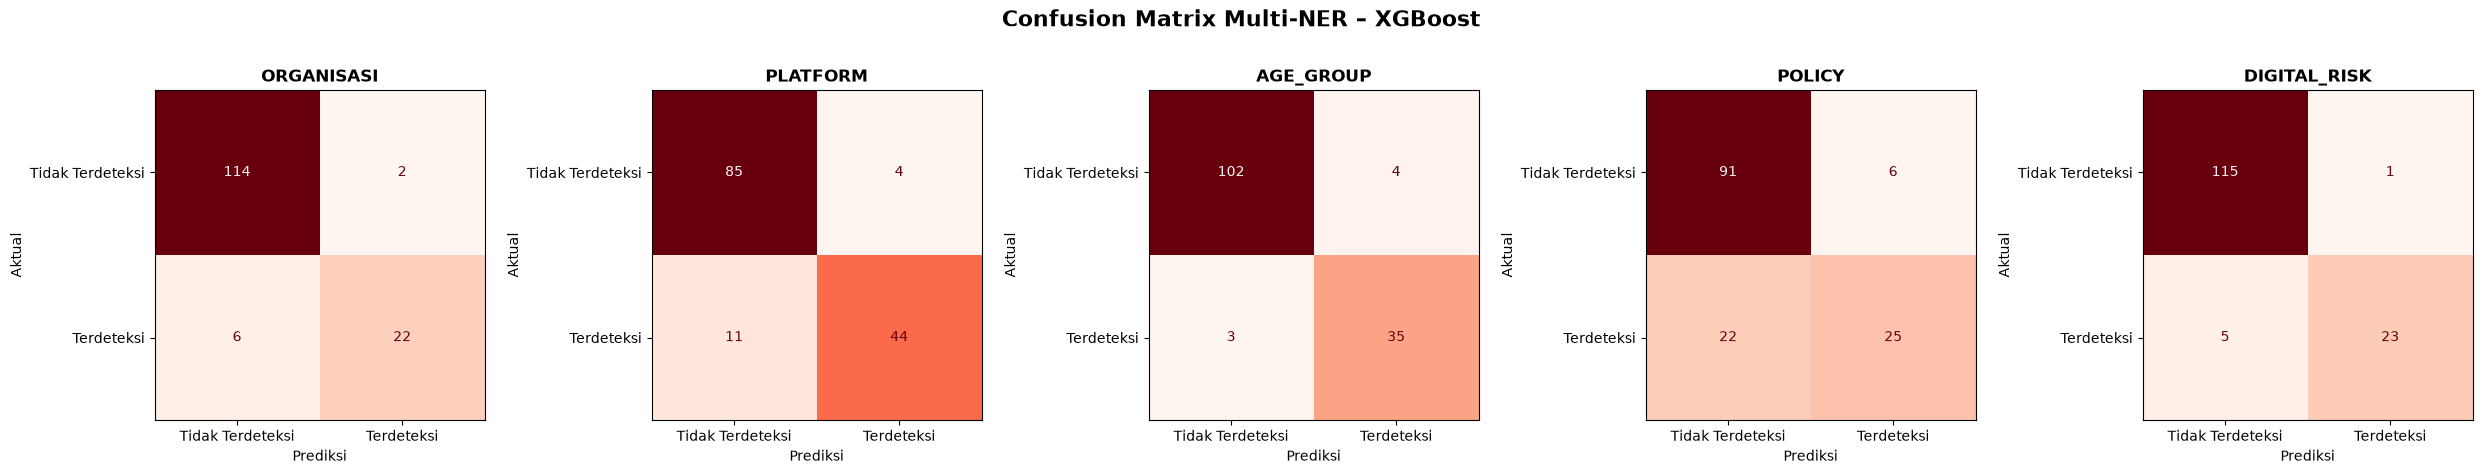

In [35]:
xgb_multilabel_cm, xgb_test_predictions = (
    build_multilabel_confusion_matrix(
        model=xgboost_search.best_estimator_,
        X_test=X_test,
        y_test=y_test,
    )
)

plot_multilabel_confusion(
    matrices=xgb_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="XGBoost",
    cmap=MODEL_CMAPS.get(
        "XGBoost",
        "Reds",
    ),
)

# 9. Ringkasan

In [36]:
evaluation_summary_df = pd.concat(
    [
        dt_metrics,
        rf_metrics,
        xgb_metrics,
    ],
    ignore_index=True,
).sort_values(
    by=[
        "f1_micro",
        "hamming_loss",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

print("Perbandingan metrik pada data test:")
display(evaluation_summary_df)

best_model_name = evaluation_summary_df.iloc[0]["model"]

print(
    "\nModel terbaik berdasarkan F1-micro tertinggi, "
    "kemudian Hamming Loss terendah:"
)
print(best_model_name)

Perbandingan metrik pada data test:


,model,hamming_loss,label_accuracy,subset_accuracy,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,f1_weighted,f1_samples,jaccard_samples
0,Random Forest,0.077778,0.922222,0.673611,0.860825,0.852041,0.856410,0.871295,0.851917,0.860505,0.856761,0.640945,0.606944
1,Decision Tree,0.083333,0.916667,0.631944,0.900000,0.780612,0.836066,0.902570,0.797181,0.845131,0.833822,0.583036,0.549190
2,XGBoost,0.088889,0.911111,0.631944,0.897590,0.760204,0.823204,0.899111,0.772022,0.827051,0.816967,0.583587,0.548380



Model terbaik berdasarkan F1-micro tertinggi, kemudian Hamming Loss terendah:
Random Forest


# 10. Simpan Hasil 

In [37]:
def confusion_matrices_to_dataframe(
    matrices,
    labels,
    model_name,
):
    rows = []

    for label, matrix in zip(labels, matrices):
        tn, fp, fn, tp = np.asarray(matrix).ravel()

        total = tn + fp + fn + tp

        accuracy = (
            (tp + tn) / total
            if total > 0
            else 0
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0
        )

        f1_score_label = (
            2 * precision * recall
            / (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        rows.append(
            {
                "model": model_name,
                "label_ner": label,
                "true_negative": int(tn),
                "false_positive": int(fp),
                "false_negative": int(fn),
                "true_positive": int(tp),
                "total_data": int(total),
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1_score": f1_score_label,
            }
        )

    return pd.DataFrame(rows)

In [38]:
dt_confusion = confusion_matrices_to_dataframe(
    matrices=dt_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="Decision Tree",
)

rf_confusion = confusion_matrices_to_dataframe(
    matrices=rf_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="Random Forest",
)

xgb_confusion = confusion_matrices_to_dataframe(
    matrices=xgb_multilabel_cm,
    labels=ENTITY_LABELS,
    model_name="XGBoost",
)

In [39]:
all_confusion_df = pd.concat(
    [
        dt_confusion,
        rf_confusion,
        xgb_confusion,
    ],
    ignore_index=True,
)

all_metrics_df = pd.concat(
    [
        dt_metrics,
        rf_metrics,
        xgb_metrics,
    ],
    ignore_index=True,
)

print("Confusion matrix seluruh algoritma:")
display(all_confusion_df)

Confusion matrix seluruh algoritma:


,model,label_ner,true_negative,false_positive,false_negative,true_positive,total_data,accuracy,precision,recall,f1_score
0,Decision Tree,ORGANISASI,113,3,3,25,144,0.958333,0.892857,0.892857,0.892857
1,Decision Tree,PLATFORM,85,4,12,43,144,0.888889,0.914894,0.781818,0.843137
2,Decision Tree,AGE_GROUP,103,3,7,31,144,0.930556,0.911765,0.815789,0.861111
3,Decision Tree,POLICY,91,6,17,30,144,0.840278,0.833333,0.638298,0.722892
4,Decision Tree,DIGITAL_RISK,115,1,4,24,144,0.965278,0.960000,0.857143,0.905660
5,Random Forest,ORGANISASI,112,4,4,24,144,0.944444,0.857143,0.857143,0.857143
6,Random Forest,PLATFORM,82,7,7,48,144,0.902778,0.872727,0.872727,0.872727
7,Random Forest,AGE_GROUP,102,4,3,35,144,0.951389,0.897436,0.921053,0.909091
8,Random Forest,POLICY,86,11,10,37,144,0.854167,0.770833,0.787234,0.778947
9,Random Forest,DIGITAL_RISK,115,1,5,23,144,0.958333,0.958333,0.821429,0.884615


In [40]:
EXCEL_RESULT_PATH = Path( OUTPUT_DIR / "NER_evaluasi_classical_ml.xlsx")

with pd.ExcelWriter(
    EXCEL_RESULT_PATH,
    engine="openpyxl",
) as writer:

    # Metrik keseluruhan setiap algoritma
    all_metrics_df.to_excel(
        writer,
        sheet_name="Metrics",
        index=False,
    )

    # Confusion matrix per label NER
    all_confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix",
        index=False,
    )

print("Excel berhasil disimpan:")
print(EXCEL_RESULT_PATH.resolve())

Excel berhasil disimpan:
D:\Magister\Semester 2\Aplikasi Pembelajaran Mesin\UAS\Outputs\Classical ML\Multi NER\NER_evaluasi_classical_ml.xlsx


# 11. Prediksi

In [41]:
data_baru = [
    "Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.",

    "WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.",

    "Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.",

    "TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.",

    "UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.",
]

print("Jumlah data baru:", len(data_baru))

for nomor, teks in enumerate(data_baru, start=1):
    print(f"{nomor}. {teks}")

Jumlah data baru: 5
1. Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.
2. WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.
3. Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.
4. TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.
5. UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.


In [42]:
models = {
    "Decision Tree": decision_tree_search.best_estimator_,
    "Random Forest": random_forest_search.best_estimator_,
    "XGBoost": xgboost_search.best_estimator_,
}

In [43]:
def get_ner_result(model, texts, labels):
    predictions = model.predict(texts)

    if hasattr(predictions, "toarray"):
        predictions = predictions.toarray()

    predictions = np.asarray(predictions)

    results = []

    for prediction in predictions:
        detected_ner = [
            label
            for index, label in enumerate(labels)
            if prediction[index] == 1
        ]

        results.append(
            ", ".join(detected_ner)
            if detected_ner
            else "Tidak ada NER terdeteksi"
        )

    return results

In [44]:
hasil_prediksi= pd.DataFrame(
    {
        "Data": data_baru,

        "Decision Tree": get_ner_result(
            decision_tree_search.best_estimator_,
            data_baru,
            ENTITY_LABELS,
        ),

        "Random Forest": get_ner_result(
            random_forest_search.best_estimator_,
            data_baru,
            ENTITY_LABELS,
        ),

        "XGBoost": get_ner_result(
            xgboost_search.best_estimator_,
            data_baru,
            ENTITY_LABELS,
        ),
    }
)

display(hasil_prediksi)

,Data,Decision Tree,Random Forest,XGBoost
0,Kementerian Kesehatan meluncurkan Program Cek ...,PLATFORM,PLATFORM,PLATFORM
1,WHO mengeluarkan kebijakan perlindungan keseha...,AGE_GROUP,AGE_GROUP,AGE_GROUP
2,Pemerintah Indonesia menjalankan Program Indon...,ORGANISASI,ORGANISASI,ORGANISASI
3,TikTok menerapkan kebijakan pembatasan penggun...,"PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP"
4,UNICEF bekerja sama dengan Kementerian Pendidi...,"PLATFORM, AGE_GROUP, POLICY","PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP"


## Buat Tabel Full

In [45]:
# Tambahkan nomor data
hasil_tampil = hasil_prediksi.copy()

hasil_tampil.insert(
    0,
    "No",
    range(1, len(hasil_tampil) + 1),
)

# Atur tampilan tabel
tabel = (
    hasil_tampil.style

    # Sembunyikan indeks bawaan DataFrame
    .hide(axis="index")

    # Format header
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("vertical-align", "top"),
                    ("padding", "10px"),
                    ("border", "1px solid black"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                ],
            },
        ]
    )

    # Kolom nomor
    .set_properties(
        subset=["No"],
        **{
            "text-align": "center",
            "width": "50px",
        },
    )

    # Kolom teks data
    .set_properties(
        subset=["Data"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "400px",
            "max-width": "600px",
        },
    )

    # Kolom hasil algoritma
    .set_properties(
        subset=[
            "Decision Tree",
            "Random Forest",
            "XGBoost",
        ],
        **{
            "text-align": "center",
            "white-space": "normal",
            "word-wrap": "break-word",
            "min-width": "170px",
            "max-width": "220px",
        },
    )
)

display(tabel)

No,Data,Decision Tree,Random Forest,XGBoost
1,Kementerian Kesehatan meluncurkan Program Cek Kesehatan Gratis melalui aplikasi SATUSEHAT untuk kelompok remaja.,PLATFORM,PLATFORM,PLATFORM
2,WHO mengeluarkan kebijakan perlindungan kesehatan mental bagi anak dan remaja pengguna Instagram.,AGE_GROUP,AGE_GROUP,AGE_GROUP
3,Pemerintah Indonesia menjalankan Program Indonesia Sehat untuk kelompok usia lanjut melalui platform digital.,ORGANISASI,ORGANISASI,ORGANISASI
4,TikTok menerapkan kebijakan pembatasan penggunaan aplikasi bagi pengguna berusia di bawah 18 tahun.,"PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP"
5,UNICEF bekerja sama dengan Kementerian Pendidikan dalam program perlindungan anak di media sosial.,"PLATFORM, AGE_GROUP, POLICY","PLATFORM, AGE_GROUP","PLATFORM, AGE_GROUP"
